### Reliability Growth Models

Software reliability growth models describe how defect discovery and failure intensity change during testing. Early test effort often finds easy defects quickly; later effort tends to uncover defects more slowly as the remaining defects become rarer, harder to trigger, or more dependent on unusual execution paths.

The Musa-Okumoto logarithmic model is one such reliability growth model. It treats cumulative discovered defects as a logarithmic curve and the instantaneous defect discovery rate as a decreasing function of testing time, making it useful for release-readiness questions such as when discovery has slowed to an acceptable rate. See ["Musa-Okumoto Logarithmic Model"](https://www.geeksforgeeks.org/software-engineering/musa-okumoto-logarithmic-model/) for more background.

This notebook generates synthetic data representative of a typical software project and shows how the M-O model can estimate the remaining, unfound defects in a system from only the subset of defects we've observed so far. This can help us plan how to reach an acceptable defect rate by the end of the project.

In [15]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike
from polars import col as c
from scipy.optimize import OptimizeResult, minimize
from scipy.special import gammaln

pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(100)

polars.config.Config

The synthetic project assumes each discovered defect makes the next one harder to find:

$$E[\Delta t_i] = \frac{1}{r_0} g^i, \qquad g = \left(\frac{r_0}{r_n}\right)^{1/(n-1)}$$

Each observed wait time is drawn from an exponential distribution with that mean.

In [16]:
def generate_reliability_growth_data(
    n_observed: int,
    initial_discovery_rate: float,
    final_discovery_rate: float,
    seed: int = 37,
):
    """Generate synthetic defect-discovery data with multiplicative reliability growth."""
    if n_observed < 1:
        raise ValueError("n_observed must be at least 1.")
    if initial_discovery_rate <= 0 or final_discovery_rate <= 0:
        raise ValueError("Discovery rates must be positive.")

    if n_observed == 1:
        reliability_growth_rate = 1.0
    else:
        reliability_growth_rate = (initial_discovery_rate / final_discovery_rate) ** (1 / (n_observed - 1))

    defect_indices = np.arange(n_observed)
    expected_times_to_find = (1 / initial_discovery_rate) * reliability_growth_rate**defect_indices

    random_generator = np.random.default_rng(seed)
    observed_times_to_find = random_generator.exponential(expected_times_to_find)
    cumulative_times = np.cumsum(observed_times_to_find)

    return pl.DataFrame(
        {
            "defects_found": defect_indices + 1,
            "delta_time": observed_times_to_find,
            "cumulative_time": cumulative_times,
        }
    )

In [17]:
def visualize_reliability_growth_data(reliability_growth_data: pl.DataFrame):
    """Plot cumulative defects found as a step function over elapsed days."""
    plot_data = reliability_growth_data.sort("cumulative_time")

    figure, axis = plt.subplots(figsize=(10, 6))
    axis.step(
        plot_data["cumulative_time"].to_numpy(),
        plot_data["defects_found"].to_numpy(),
        where="post",
        linewidth=2,
    )

    axis.set_title("Defect Discovery")
    axis.set_xlabel("Cumulative testing time (days)")
    axis.set_ylabel("Defects found")
    axis.grid(True, alpha=0.35)
    plt.show()

The Musa-Okumoto model uses a logarithmic mean-value function and a decreasing discovery rate:

$$m(t) = \frac{\log(1 + \lambda_0 \theta t)}{\theta}, \qquad \lambda(t) = \frac{\lambda_0}{1 + \lambda_0 \theta t}$$

In [18]:
class MusaOkumotoModel:
    """Store a fitted Musa-Okumoto model."""

    def __init__(self, initial_failure_intensity: float, decay_parameter: float, fit_result: OptimizeResult | None):
        """Initialize model parameters."""
        self.initial_failure_intensity = initial_failure_intensity
        self.decay_parameter = decay_parameter
        self.fit_result = fit_result

    def expected_defects_found(self, cumulative_time: ArrayLike):
        """Return the expected cumulative defects."""
        cumulative_time = np.asarray(cumulative_time)
        return np.log1p(self.initial_failure_intensity * self.decay_parameter * cumulative_time) / self.decay_parameter

    def defect_discovery_rate(self, cumulative_time: ArrayLike):
        """Return the instantaneous discovery rate."""
        cumulative_time = np.asarray(cumulative_time)
        return self.initial_failure_intensity / (1 + self.initial_failure_intensity * self.decay_parameter * cumulative_time)

    def cumulative_time_at_rate(self, defect_discovery_rate: float):
        """Return when the fitted rate reaches a target."""
        if defect_discovery_rate <= 0:
            raise ValueError("defect_discovery_rate must be positive.")

        threshold_time = (self.initial_failure_intensity / defect_discovery_rate - 1) / (
            self.initial_failure_intensity * self.decay_parameter
        )
        return max(threshold_time, 0.0)

    def expected_defects_found_at_rate(self, defect_discovery_rate: float):
        """Return cumulative defects at a target rate."""
        threshold_time = self.cumulative_time_at_rate(defect_discovery_rate)
        return self.expected_defects_found(threshold_time)


def fit_musa_okumoto_model(reliability_growth_data: pl.DataFrame):
    """Fit a Musa-Okumoto model."""
    fit_data = reliability_growth_data.sort("cumulative_time")
    observed_times = np.r_[0.0, fit_data["cumulative_time"].to_numpy()]
    observed_defects = np.r_[0.0, fit_data["defects_found"].to_numpy()]

    def negative_log_likelihood(parameters: ArrayLike):
        """Score parameters by Poisson increments."""
        initial_failure_intensity, decay_parameter = parameters
        if initial_failure_intensity <= 0 or decay_parameter <= 0:
            return np.inf

        model = MusaOkumotoModel(initial_failure_intensity, decay_parameter, fit_result=None)
        expected_defects = model.expected_defects_found(observed_times)
        expected_increments = np.diff(expected_defects)
        observed_increments = np.diff(observed_defects)

        if np.any(~np.isfinite(expected_increments)) or np.any(expected_increments <= 0):
            return np.inf

        return np.sum(
            expected_increments
            - observed_increments * np.log(expected_increments)
            + gammaln(observed_increments + 1)
        )

    total_observed_defects = observed_defects[-1]
    total_observed_time = max(observed_times[-1], 1e-9)
    starting_guess = np.array([total_observed_defects / total_observed_time, 0.02])

    fit_result = minimize(
        negative_log_likelihood,
        x0=starting_guess,
        bounds=[(1e-9, None), (1e-9, None)],
        method="L-BFGS-B",
    )

    return MusaOkumotoModel(
        initial_failure_intensity=fit_result.x[0],
        decay_parameter=fit_result.x[1],
        fit_result=fit_result,
    )

In [19]:
def visualize_reliability_growth_fit(
    observed_data: pl.DataFrame,
    complete_data: pl.DataFrame,
    fitted_model: MusaOkumotoModel,
    acceptable_defect_days: float = 7,
):
    """Plot observed, future, fitted, and threshold data."""
    observed_plot_data = observed_data.sort("cumulative_time")
    complete_plot_data = complete_data.sort("cumulative_time")
    observed_end_time = observed_plot_data["cumulative_time"].max()
    maximum_time = complete_plot_data["cumulative_time"].max()
    observed_defect_count = observed_plot_data["defects_found"].max()
    acceptable_defect_discovery_rate = 1 / acceptable_defect_days
    acceptable_defect_time = fitted_model.cumulative_time_at_rate(acceptable_defect_discovery_rate)
    acceptable_defects_found = fitted_model.expected_defects_found(acceptable_defect_time)

    future_plot_data = complete_plot_data.filter(c("cumulative_time") >= observed_end_time)
    curve_times = np.linspace(0.0, max(maximum_time, acceptable_defect_time), 500)
    fitted_defects = fitted_model.expected_defects_found(curve_times)

    figure, axis = plt.subplots(figsize=(10, 6))
    axis.step(
        observed_plot_data["cumulative_time"].to_numpy(),
        observed_plot_data["defects_found"].to_numpy(),
        where="post",
        linewidth=1,
        marker=".",
        markersize=6,
        label=f"Observed Defects (N={observed_defect_count})",
        zorder=10,
    )
    axis.step(
        future_plot_data["cumulative_time"].to_numpy(),
        future_plot_data["defects_found"].to_numpy(),
        where="post",
        linestyle="--",
        linewidth=1,
        color="0.35",
        label="Unobserved Defects (Test set)",
        zorder=2,
    )
    axis.axvline(
        observed_end_time,
        linestyle=":",
        linewidth=1,
        color="0.2",
        label=f"End Of Observed Data (Day {observed_end_time:.0f})",
        zorder=1,
    )
    axis.axvline(
        acceptable_defect_time,
        linestyle=":",
        linewidth=1,
        color="green",
        zorder=1,
    )
    axis.axhline(
        acceptable_defects_found,
        linestyle=":",
        linewidth=1,
        color="green",
        zorder=1,
    )
    axis.scatter(
        [acceptable_defect_time],
        [acceptable_defects_found],
        color="green",
        s=20,
        label=f"One Defect Every {acceptable_defect_days:g} Days",
        zorder=11,
    )
    axis.plot(
        curve_times,
        fitted_defects,
        linewidth=1,
        color="tab:orange",
        label="Musa-Okumoto Fit",
        zorder=3,
    )

    axis.set_title("Musa-Okumoto Reliability Growth Model")
    axis.set_xlabel("Cumulative Testing Time (Days)")
    axis.set_ylabel("Defects Found")
    axis.grid(True, alpha=0.35)
    axis.legend(loc="lower right")
    plt.show()

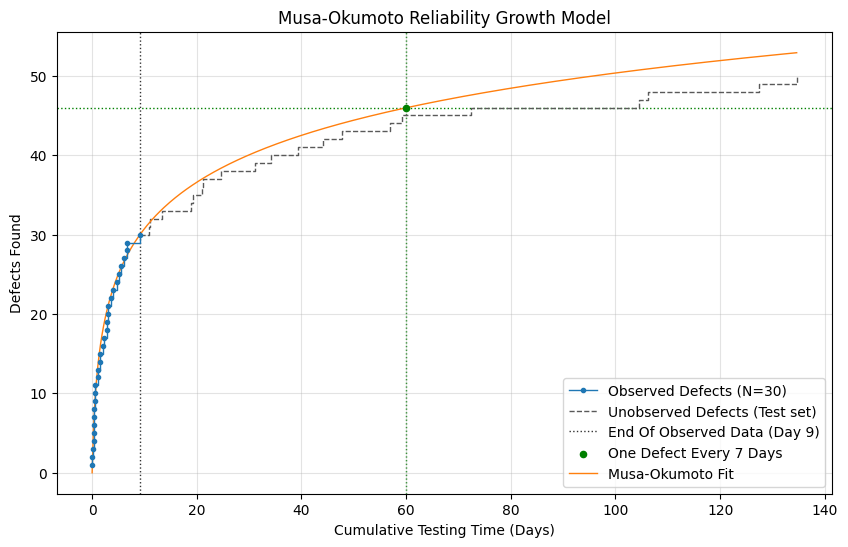

In [20]:
# A system has 100 defects total to find.
# At the beginning of the project, it is trivial to find 20 defects in a single day.
# By the end, the same level of testing only finds one new defect every ten days.
# We only observe the first 30 days of the generated data.
all_data = generate_reliability_growth_data(
    n_observed=50,
    initial_discovery_rate=20,
    final_discovery_rate=0.1,
    seed=3,
)
data = all_data.filter(c("cumulative_time") <= 10)

fitted_model = fit_musa_okumoto_model(data)
visualize_reliability_growth_fit(data, all_data, fitted_model)

In [21]:
from ipywidgets import interact, FloatLogSlider, FloatSlider, IntSlider, Layout


def interact_with_reliability_growth_fit(
    n_observed: int = 50,
    initial_discovery_rate: float = 20,
    final_discovery_rate: float = 0.1,
    seed: int = 3,
    observation_days: float = 10,
    acceptable_defect_days: int = 7,
):
    """Regenerate, refit, and redraw the demo."""
    all_data = generate_reliability_growth_data(
        n_observed=n_observed,
        initial_discovery_rate=initial_discovery_rate,
        final_discovery_rate=final_discovery_rate,
        seed=seed,
    )
    data = all_data.filter(c("cumulative_time") <= observation_days)

    fitted_model = fit_musa_okumoto_model(data)
    visualize_reliability_growth_fit(
        data,
        all_data,
        fitted_model,
        acceptable_defect_days=acceptable_defect_days,
    )


slider_style = {"description_width": "200px"}
slider_layout = Layout(width="520px")

interact(
    interact_with_reliability_growth_fit,
    n_observed=IntSlider(
        value=50,
        min=10,
        max=200,
        step=5,
        description="Total Number of Defects",
        style=slider_style,
        layout=slider_layout,
    ),
    initial_discovery_rate=FloatLogSlider(
        value=20,
        base=10,
        min=1,
        max=2,
        step=0.01,
        readout_format=".2f",
        description="Initial Rate",
        style=slider_style,
        layout=slider_layout,
    ),
    final_discovery_rate=FloatLogSlider(
        value=0.1,
        base=10,
        min=-3,
        max=np.log10(5),
        step=0.001,
        readout_format=".3f",
        description="Final Rate",
        style=slider_style,
        layout=slider_layout,
    ),
    seed=IntSlider(
        value=3,
        min=0,
        max=100,
        step=1,
        description="Seed",
        style=slider_style,
        layout=slider_layout,
    ),
    observation_days=FloatSlider(
        value=10,
        min=1,
        max=100,
        step=1,
        readout_format=".0f",
        description="Observation Days",
        style=slider_style,
        layout=slider_layout,
    ),
    acceptable_defect_days=IntSlider(
        value=7,
        min=1,
        max=30,
        step=1,
        description="Acceptable Defect Rate (Days)",
        style=slider_style,
        layout=slider_layout,
    ),
);

interactive(children=(IntSlider(value=50, description='Total Number of Defects', layout=Layout(width='520px'),…